stratified split por especie

In [1]:
import pandas as pd
import numpy as np

FEAT_PATH = r"C:\Users\santi\Documents\pyrolisis\Data\pyrolysis_features.csv"
df = pd.read_csv(FEAT_PATH)

print("Dataset cargado:", df.shape)

Dataset cargado: (512, 21)


In [2]:
conteo = df['Biomass species'].value_counts()
print(conteo[conteo < 5])
print(f"\nTotal afectadas: {(conteo < 5).sum()}")

Biomass species
Jerusalem artichoke stick        4
reed                             4
Ponytail                         4
Rice husk                        4
Beech                            4
Southern bimorphic microalgae    4
pomegranate seeds                4
paulownia wood                   4
S. japonica                      4
wheat stalk                      3
Wheat straw                      3
DOC                              3
corn                             3
Peanut shells                    1
Dried banana leaves              1
Sugarcane straw                  1
wheat straw                      1
Miscanthus sinensis              1
Willow                           1
Palm shell                       1
EFB                              1
Mesocarp fiber                   1
Palm trunk                       1
Thallus                          1
Leaf                             1
Leaf rib                         1
Name: count, dtype: int64

Total afectadas: 26


In [4]:
# Separar especies con al menos 5 muestras de las que tienen menos de 5
conteo = df['Biomass species'].value_counts()
especies_ok = conteo[conteo >= 5].index
especies_pocas = conteo[conteo < 5].index
# Crear conjuntos de entrenamiento y prueba
from sklearn.model_selection import train_test_split
# Para las especies con suficientes muestras, hacemos un split estratificado
df_ok = df[df['Biomass species'].isin(especies_ok)]
df_pocas = df[df['Biomass species'].isin(especies_pocas)]
# El conjunto de entrenamiento incluirá todas las especies con pocas muestras y un split del resto
train_ok, test = train_test_split(df_ok, test_size=0.2, random_state=42, 
                                   stratify=df_ok['Biomass species'])
# Agregamos todas las muestras de las especies con pocas muestras al entrenamiento
train = pd.concat([train_ok, df_pocas], ignore_index=True)
# Verificar los tamaños de los conjuntos
print("Train:", train.shape)
print("Test:", test.shape)
# Verificar la distribución de especies en el entrenamiento
print(train['Biomass species'].value_counts())


Train: (421, 21)
Test: (91, 21)
Biomass species
rapeseed                   29
Lampranthus spectabilis    25
sugar cane                 18
safflower seed             18
sunflower                  16
                           ..
Mesocarp fiber              1
Palm trunk                  1
Thallus                     1
Leaf                        1
Leaf rib                    1
Name: count, Length: 62, dtype: int64


In [8]:
# Selección de características
features = ['H_C', 'O_C', 'N', 'Ash ', 'VM', 'FC', 'M', 
            'FT', 'FT_squared', 'HR', 'PS', 'FR', 'FR_disponible']
#features = ["C","H","O","N","Ash ","VM","FC"]
X_train = train[features]
X_test = test[features]
y_train = train['Liquid phase']
y_test = test['Liquid phase']

print(X_train.shape, X_test.shape)

(421, 13) (91, 13)


In [ ]:
# Modelado
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
# entrenar
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

# predecir
y_pred_lr = model_lr.predict(X_test)

# evaluar
r2 = r2_score(y_test, y_pred_lr)
mae = mean_absolute_error(y_test, y_pred_lr)

print(f"R²: {r2:.3f}")
print(f"MAE: {mae:.3f}")

R²: 0.496
MAE: 6.207


In [13]:
!pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)


In [14]:
from xgboost import XGBRegressor

model_xgb = XGBRegressor(random_state=42)
model_xgb.fit(X_train, y_train)

y_pred_xgb = model_xgb.predict(X_test)

r2_xgb = r2_score(y_test, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

print(f"R²: {r2_xgb:.3f}")
print(f"MAE: {mae_xgb:.3f}")

R²: 0.879
MAE: 2.560


In [15]:
y_pred_train = model_xgb.predict(X_train)
r2_train = r2_score(y_train, y_pred_train)
mae_train = mean_absolute_error(y_train, y_pred_train)

print(f"Train - R²: {r2_train:.3f} | MAE: {mae_train:.3f}")
print(f"Test  - R²: {r2_xgb:.3f} | MAE: {mae_xgb:.3f}")

Train - R²: 0.994 | MAE: 0.337
Test  - R²: 0.879 | MAE: 2.560


In [16]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model_xgb, X_train, y_train, 
                         cv=5, scoring='r2')

print("R² por fold:", scores.round(3))
print(f"R² promedio: {scores.mean():.3f} ± {scores.std():.3f}")

R² por fold: [0.83  0.89  0.877 0.881 0.066]
R² promedio: 0.709 ± 0.322


In [17]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5)
for i, (train_idx, val_idx) in enumerate(kf.split(X_train)):
    X_f = X_train.iloc[train_idx]
    X_v = X_train.iloc[val_idx]
    y_f = y_train.iloc[train_idx]
    y_v = y_train.iloc[val_idx]
    
    model_xgb.fit(X_f, y_f)
    r2 = r2_score(y_v, model_xgb.predict(X_v))
    print(f"Fold {i+1}: R²={r2:.3f} | n_val={len(val_idx)} | "
          f"Liquid mean={y_v.mean():.1f} std={y_v.std():.1f}")

Fold 1: R²=0.830 | n_val=85 | Liquid mean=40.6 std=10.0
Fold 2: R²=0.890 | n_val=84 | Liquid mean=42.1 std=12.6
Fold 3: R²=0.877 | n_val=84 | Liquid mean=40.8 std=11.4
Fold 4: R²=0.881 | n_val=84 | Liquid mean=40.4 std=10.6
Fold 5: R²=0.066 | n_val=84 | Liquid mean=40.9 std=11.8


In [18]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model_xgb, X_train, y_train,
                         cv=skf.split(X_train, train['Biomass species']),
                         scoring='r2')

print("R² por fold:", scores.round(3))
print(f"R² promedio: {scores.mean():.3f} ± {scores.std():.3f}")

c:\Users\santi\Envs\wqa\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


R² por fold: [0.852 0.776 0.864 0.819 0.861]
R² promedio: 0.835 ± 0.033


Regresión lineal test: 0.496
XGBoost test: 0.879
XGBoost CV estratificado: 0.835

Se comenzó con un baseline de Regresión Lineal para fijar un piso de desempeño y testear si una relación aproximadamente lineal entre features y Yield alcanzaba; el modelo obtuvo R² = 0.496.
Se pasó a XGBoost porque el proceso muestra no linealidades e interacciones (efectos combinados entre variables) que la regresión lineal no puede representar sin especificarlas a mano.
Se utilizó cross-validation (CV) para estimar desempeño de forma más robusta que un único train/test split: se entrena y evalúa en varios folds y se promedian métricas, reduciendo la dependencia de una partición.
El XGBoost mejoró el desempeño en el split de test con R² = 0.879 y mantuvo un rendimiento estable en validación con R² CV = 0.835, consistente con una mejora real sobre el baseline y no solo sobreajuste al split.

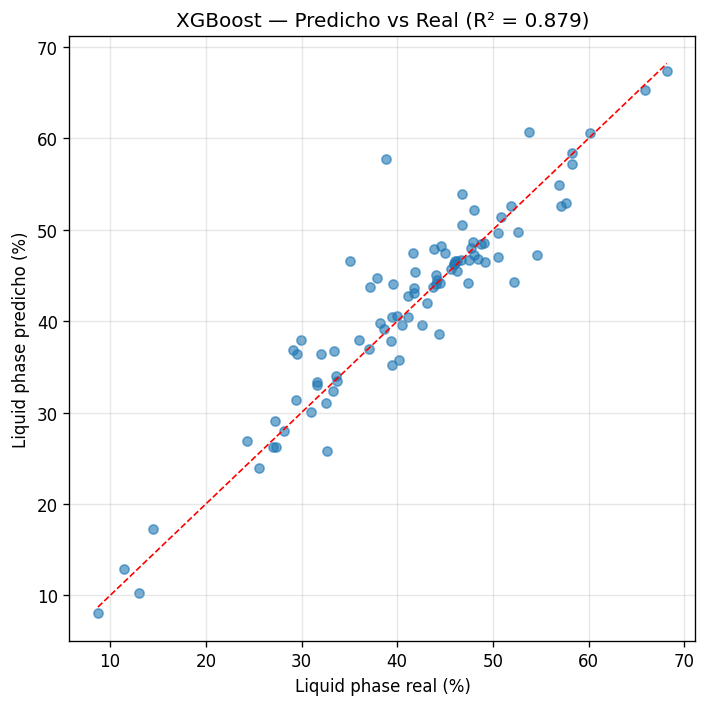

In [19]:
import matplotlib.pyplot as plt

y_pred_xgb = model_xgb.predict(X_test)

fig, ax = plt.subplots(figsize=(6,6), dpi=120)

# scatter: real vs predicho
ax.scatter(y_test, y_pred_xgb, alpha=0.6, s=30)

# línea perfecta y=x
lims = [y_test.min(), y_test.max()]  # min y max del eje
ax.plot(lims, lims, 'r--', linewidth=1)

ax.set_xlabel("Liquid phase real (%)")
ax.set_ylabel("Liquid phase predicho (%)")
ax.set_title(f"XGBoost — Predicho vs Real (R² = {r2_xgb:.3f})")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

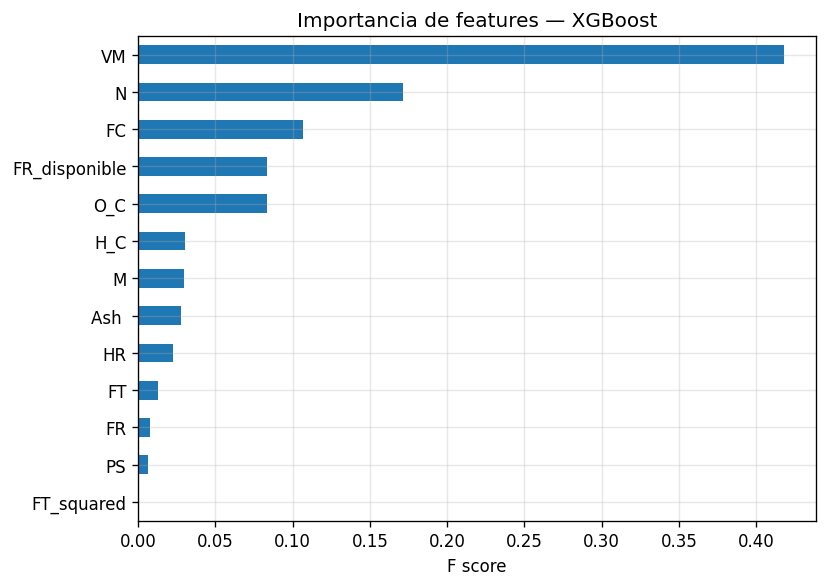

In [20]:
import pandas as pd

importances = pd.Series(model_xgb.feature_importances_, index=features)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 5), dpi=120)
importances.plot(kind='barh', ax=ax)
ax.set_title("Importancia de features — XGBoost")
ax.set_xlabel("F score")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
import os
os.makedirs(r"C:\Users\santi\Documents\pyrolisis\models", exist_ok=True)
joblib.dump(model_xgb, r"C:\Users\santi\Documents\pyrolisis\models\xgb_liquid.pkl")
print("Modelo guardado")

Modelo guardado


El modelo confirma que los drivers principales son composicionales: VM, N y FC aparecen entre las variables más influyentes. Esto es coherente con la química de la pirólisis. Mayor VM implica mayor fracción térmicamente lábil, susceptible a despolimerización y cracking primario, afectando directamente la distribución de fases. Mayor FC representa una matriz más carbonizada y aromática, asociada a mayor formación de sólido y menor liberación de volátiles. Que N esté en el top 3 es relevante: casi se elimina durante la limpieza y sin embargo captura diferencias reales de composición, probablemente vinculadas a fracciones proteicas con comportamiento térmico distinto al de polisacáridos.

FT_squared muestra importancia casi nula. Esto no contradice el EDA previo donde la relación con temperatura era cuadrática; XGBoost modela no linealidades internamente mediante particiones sucesivas, por lo que la transformación explícita FT² resulta redundante en este contexto.

Finalmente, FR_disponible aparece entre las variables más importantes. Esto valida la decisión de ingeniería de features: el hecho de que el caudal haya sido medido o imputado contiene señal predictiva real, probablemente porque captura diferencias metodológicas entre protocolos experimentales, funcionando como variable de trazabilidad con impacto en el rendimiento.